In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
class gpt2Config:

    def __init__(self):

        self.vocab_size = 50257
        self.d_model = 256
        self.n_heads = 4
        self.n_decoder = 4
        self.hidden_states = 1024
        self.dropout_p = 0.2
        self.block_size = 700
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

config = gpt2Config()

In [4]:
class Embedding(nn.Module):

    def __init__(self, config):

        super().__init__()

        self.token_embedding = nn.Embedding(config.vocab_size, config.d_model)
        self.position_embedding = nn.Embedding(config.block_size, config.d_model)

    def forward(self, x):
        B, T = x.size()          # B, T
        tok_embedding = self.token_embedding(x)   # B,T,C

        pos_range = torch.arange(0, T, device = x.device)   # T
        pos_embedding = self.position_embedding(pos_range)  # T, C

        return tok_embedding + pos_embedding

In [5]:
class HeadAttention(nn.Module):

    def __init__(self, config):
        super().__init__()

        self.config = config
        self.attn_dropout = nn.Dropout(config.dropout_p)
        self.q_mat = nn.Linear(config.d_model, config.d_model, bias = False)
        self.k_mat = nn.Linear(config.d_model, config.d_model, bias = False)
        self.v_mat = nn.Linear(config.d_model, config.d_model, bias = False)
        self.out_proj = nn.Linear(config.d_model, config.d_model, bias = False)


    def forward(self, x):

        B, T, C = x.size()

        que = self.q_mat(x)    # B, T, C
        key = self.k_mat(x)
        val = self.v_mat(x)

        assert self.config.d_model % self.config.n_heads == 0, "d_model should be divided by n_heads"

        n_que = que.view(B, T, self.config.n_heads, C//self.config.n_heads).permute(0, 2, 1, 3)   # B, n_heads, T, d_heads
        n_key = key.view(B, T, self.config.n_heads, C//self.config.n_heads).permute(0, 2, 1, 3)
        n_val = val.view(B, T, self.config.n_heads, C//self.config.n_heads).permute(0, 2, 1, 3)

        attn_score = n_que @ n_key.transpose(-2, -1) * (1.0 / math.sqrt(C//self.config.n_heads))

        casual_mask = torch.triu(torch.ones(T, T, device = x.device), diagonal = 1)
        casual_masked = casual_mask.masked_fill(casual_mask==1, float('-inf'))

        attn_score = attn_score + casual_masked

        attn = F.softmax(attn_score, dim = -1)

        attn = self.attn_dropout(attn)

        attn = attn @ n_val     # B, n_heads, T, d_heads

        attn = attn.permute(0, 2, 1, 3).reshape(B, T, -1)

        attn = self.out_proj(attn)

        return attn

In [6]:
class LayerNormalization(nn.Module):

    def __init__(self, config):

        super().__init__()
        self.beta  = nn.Parameter(torch.zeros(config.d_model))
        self.gamma = nn.Parameter(torch.ones(config.d_model))

    def forward(self, x, eps=1e-5):

        B, T, C = x.size()
        mean = torch.mean(x, dim = -1, keepdim = True)    # B, T, 1
        std = torch.std(x, dim = -1, keepdim = True, unbiased=False)

        Z = (x - mean) / (std + eps)
        return Z * self.gamma + self.beta

In [7]:
class FFNN(nn.Module):

    def __init__(self, config):

        super().__init__()

        self.layer1 = nn.Linear(config.d_model, 4 * config.d_model, bias = False)
        self.ffnn_dropout = nn.Dropout(config.dropout_p)
        self.layer2 = nn.Linear(4 * config.d_model, config.d_model, bias = False)

    def forward(self, x):
        return self.layer2(self.ffnn_dropout(F.gelu(self.layer1(x), approximate='tanh')))

In [8]:
class OneDecoder(nn.Module):

    def __init__(self, config):

        super().__init__()

        self.mha = HeadAttention(config)
        self.layer_norm1 = LayerNormalization(config)
        self.ffnn = FFNN(config)
        self.layer_norm2 = LayerNormalization(config)

    def forward(self, x):
        x = self.layer_norm1(x)
        x = x + self.mha(x)

        x = self.layer_norm2(x)
        x = x + self.ffnn(x)

        return x

In [9]:
class DecoderStack(nn.Module):

    def __init__(self, config):

        super().__init__()

        self.layernorm = LayerNormalization(config)
        self.n_Decoders = nn.ModuleList([OneDecoder(config) for _ in range(config.n_decoder)])

    def forward(self, x):

        for layer in self.n_Decoders:
            x = layer(x)
        hidden_states = self.layernorm(x)
        return hidden_states

In [10]:
def init_weights(module):
    if isinstance(module, nn.Linear):
        nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if module.bias is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, nn.Embedding):
        nn.init.normal_(module.weight, mean=0.0, std=0.02)
    elif isinstance(module, LayerNormalization):
        nn.init.ones_(module.gamma)
        nn.init.zeros_(module.beta)

In [11]:
class GPT2(nn.Module):

    def __init__(self, config):

        super().__init__()

        self.Embeddings = Embedding(config)
        self.decoder_stack = DecoderStack(config)
        self.projection_layer = nn.Linear(config.d_model, config.vocab_size, bias = False)

    def forward(self, x, target = None):

        x = self.Embeddings(x)
        hidden_states = self.decoder_stack(x)
        logits = self.projection_layer(hidden_states)

        loss = None
        if target is not None:                                             # if we have target then we will compute loss.
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                target.view(-1),                                       # entropy = -log(target_index_of_logits) other rest will be 0
                ignore_index = tokenizer.encode(tokenizer.pad_token)[0]
            )
        return logits, loss


    def generate(self, ids, max_new_token: int, temp: float = 1.0):

        with torch.no_grad():
          ids = ids[:, :config.block_size] if ids.size(1) > config.block_size else ids  # truncating so that the ids don't exceed blocksize.
          for _ in range(max_new_token):
              logits, _ = self(ids)
              logits = logits[:, -1, :] / temp
              norm_logits = F.softmax(logits, dim = -1)
              o_token_index = torch.multinomial(norm_logits, 1)
              ids = torch.cat((ids, o_token_index), dim = -1)
        return ids


    def calculate_log_probs(self, completion_in, completion_out):
        output_logits, _ = self(completion_in)  # B, T, C
        log_probs = F.log_softmax(output_logits, dim = -1)
        choosen_log_probs = log_probs.gather(-1, completion_out.unsqueeze(-1)).squeeze(-1)   # --> .gather(which_dimension_of output_logits, which index)
        return choosen_log_probs

In [12]:
gpt2 = GPT2(config)
gpt2.apply(init_weights)

GPT2(
  (Embeddings): Embedding(
    (token_embedding): Embedding(50257, 256)
    (position_embedding): Embedding(700, 256)
  )
  (decoder_stack): DecoderStack(
    (layernorm): LayerNormalization()
    (n_Decoders): ModuleList(
      (0-3): 4 x OneDecoder(
        (mha): HeadAttention(
          (attn_dropout): Dropout(p=0.2, inplace=False)
          (q_mat): Linear(in_features=256, out_features=256, bias=False)
          (k_mat): Linear(in_features=256, out_features=256, bias=False)
          (v_mat): Linear(in_features=256, out_features=256, bias=False)
          (out_proj): Linear(in_features=256, out_features=256, bias=False)
        )
        (layer_norm1): LayerNormalization()
        (ffnn): FFNN(
          (layer1): Linear(in_features=256, out_features=1024, bias=False)
          (ffnn_dropout): Dropout(p=0.2, inplace=False)
          (layer2): Linear(in_features=1024, out_features=256, bias=False)
        )
        (layer_norm2): LayerNormalization()
      )
    )
  )
  (proj

In [13]:
print(f'{sum(p.numel() for p in gpt2.parameters())/1e6 :.2f} MILLIONS PARAMETER!!')

29.06 MILLIONS PARAMETER!!


# **DATASETS PART**

In [ ]:
!pip install -U transformers

In [14]:
from transformers import GPT2Tokenizer
from datasets import load_dataset

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

In [15]:
tokenizer

GPT2Tokenizer(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}
)

In [16]:
dataset = load_dataset('CarperAI/openai_summarize_tldr')
print(dataset)

training_dataset = dataset['train']
validation_dataset = dataset['valid']

training_dataset = training_dataset.select(range(80000))

README.md:   0%|          | 0.00/532 [00:00<?, ?B/s]

data/train-00000-of-00001-e8c59e5cf7bce1(…):   0%|          | 0.00/111M [00:00<?, ?B/s]

data/test-00000-of-00001-59ffb27399371ea(…):   0%|          | 0.00/6.23M [00:00<?, ?B/s]

data/valid-00000-of-00001-0e33e6bd86e3ed(…):   0%|          | 0.00/6.12M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/116722 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6553 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/6447 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['prompt', 'label'],
        num_rows: 116722
    })
    test: Dataset({
        features: ['prompt', 'label'],
        num_rows: 6553
    })
    valid: Dataset({
        features: ['prompt', 'label'],
        num_rows: 6447
    })
})


In [19]:
def tokenizing(ds):
    tokenized = tokenizer(ds['prompt'])
    return tokenized

train_tok_dataset = training_dataset.map(tokenizing, batched = True, remove_columns = training_dataset.column_names)
valid_tok_dataset = validation_dataset.map(tokenizing, batched = True, remove_columns = training_dataset.column_names)

Map:   0%|          | 0/80000 [00:00<?, ? examples/s]

Map:   0%|          | 0/6447 [00:00<?, ? examples/s]

In [21]:
train_tok_dataset

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 80000
})

In [24]:
tokenizer.encode(tokenizer.pad_token)

[50256]

In [36]:
from torch.utils.data import Dataset, DataLoader


class MyCustomDataset(Dataset):

    def __init__(self, ds):

        self.input_ids = ds['input_ids']

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        tokens = self.input_ids[idx]

        if len(tokens) > config.block_size+1:
          tokens = tokens[:config.block_size+1]

        else:
          tokens = tokens + [50256] * (config.block_size+1 - len(tokens))

        tokens = torch.tensor(tokens, dtype = torch.long, device = config.device)

        input_tokens = tokens[:-1]
        output_tokens = tokens[1:]

        return {
            "x": input_tokens,
            "y": output_tokens
        }

TrainDataset = MyCustomDataset(train_tok_dataset)
ValidDataset = MyCustomDataset(valid_tok_dataset)

In [37]:
train_data = DataLoader(TrainDataset, batch_size = 8, shuffle = True) #, num_workers = 2)
valid_data = DataLoader(ValidDataset, batch_size = 8, shuffle = False)

In [42]:
gpt2 = gpt2.to(config.device)

In [43]:
optimizer = torch.optim.AdamW(gpt2.parameters(), lr = 1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=800, eta_min=1e-5)

In [44]:
from tqdm import tqdm

In [45]:
from torch.amp import autocast, GradScaler
import os

scaler = GradScaler(device="cuda")

total_steps = 9
training_losses = []
validation_losses = []

for step in range(total_steps):
    train_loss, train_size = 0, 0
    valid_loss, valid_size = 0, 0

    gpt2.train()
    for batch in tqdm(train_data):
        x, y = batch['x'].to(config.device), batch['y'].to(config.device)

        optimizer.zero_grad()

        # forward + loss in autocast
        with autocast(device_type="cuda"):
            logits, loss = gpt2(x, y)

        if loss is None:
            raise ValueError("Loss is None! Check targets.")

        # scale and backpropagate
        scaler.scale(loss).backward()

        # unscale before gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(gpt2.parameters(), max_norm=1.0)

        # optimizer step (only once per batch)
        scaler.step(optimizer)
        scaler.update()

        # scheduler step
        scheduler.step()

        train_loss += loss.item() * x.size(0)
        train_size += x.size(0)

    save_path = '/content/drive/MyDrive/gpt2_checkpoints/'
    os.makedirs(save_path, exist_ok=True)

    # save model weights
    name = f'model_weights{step}.pt'
    torch.save(gpt2.state_dict(), os.path.join(save_path, name))
    print("Model weights saved to Google Drive!")

    # validation
    gpt2.eval()
    with torch.no_grad():
        for batch in tqdm(valid_data):
            x, y = batch['x'].to(config.device), batch['y'].to(config.device)
            with autocast(device_type="cuda"):
                logits, loss = gpt2(x, y)
            valid_loss += loss.item() * x.size(0)
            valid_size += x.size(0)

    training_losses.append(train_loss / train_size)
    validation_losses.append(valid_loss / valid_size)

    print(f"Step {step+1}/{total_steps} | Train Loss: {train_loss/train_size :.2f} | Valid Loss: {valid_loss/valid_size:.2f}")

100%|██████████| 10000/10000 [23:11<00:00,  7.19it/s]


Model weights saved to Google Drive!


100%|██████████| 806/806 [00:42<00:00, 19.04it/s]


Step 1/9 | Train Loss: 3.92 | Valid Loss: 3.55


100%|██████████| 10000/10000 [23:07<00:00,  7.21it/s]


...

Step 8/9 | Train Loss: 3.19 | Valid Loss: 3.30


100%|██████████| 10000/10000 [23:01<00:00,  7.24it/s]


Model weights saved to Google Drive!


100%|██████████| 806/806 [00:42<00:00, 19.13it/s]

Step 9/9 | Train Loss: 3.17 | Valid Loss: 3.26


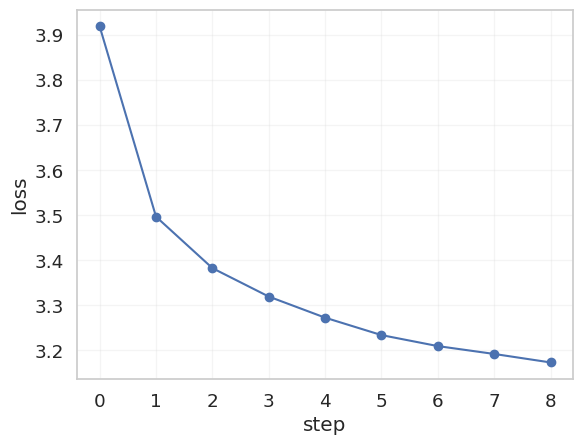

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.2)
plt.plot(training_losses, marker = 'o')

plt.xlabel("step")
plt.ylabel("loss")
plt.grid(True, alpha = 0.2)
plt.show()

In [ ]:
torch.save(gpt2.state_dict(), 'model_weights.pt')

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import os

# create a folder in Drive (optional)
save_path = '/content/drive/MyDrive/gpt2_checkpoints/'
os.makedirs(save_path, exist_ok=True)

# save model weights
torch.save(gpt2.state_dict(), os.path.join(save_path, 'model_weights.pt'))
print("Model weights saved to Google Drive!")

Model weights saved to Google Drive!


# **INFERENCE**

In [ ]:
gpt2 = GPT2(config)

In [ ]:
weights_path = "/content/drive/MyDrive/gpt2_checkpoints/model_weights.pt"

state_dict = torch.load(weights_path, map_location = config.device)
gpt2.load_state_dict(state_dict)

<All keys matched successfully>

In [46]:
_ = gpt2.eval()
_ = gpt2.to(config.device)

In [47]:
def generate_texts(text: str, model, max_new_token, temp = 1.0):
  token_ids = tokenizer.encode(text)
  token_ids = torch.tensor(token_ids, dtype = torch.long).to(config.device).unsqueeze(0)
  response_id = model.generate(token_ids, max_new_token, temp)
  return print(f'Generated Texts:\n{'=' * 16}\n\n{tokenizer.decode(list(response_id[0]), skip_special_tokens = True)}')

In [48]:
#I will lift my private bus today and this awesome girl I've gone to private bus today and this awesome girl I've gone to

In [58]:
query = "SUBREDDIT: r/relationships"
generate_texts(query, gpt2, 60)

Generated Texts:

SUBREDDIT: r/relationships
TITLE: Me [19 M] with my GF [20 F] of 8 months, just started hiking with 12 months ago. I want to break up. Maybe because the rest of my relationship with my GF
POST: I went to a hiking city just getting serious with her, though
